<span style='font-size:40px; display:block;'>
<b>
    Ustar filtering
</b>
</br>

---

# **BACKGROUND**

---

Filtering NEE, FN2O and FCH4 using the seasonal ustar thresholds detected with ReddyProc.
The purpose is to exclude fluxes calculated in periods with insufficient turbulence, thus avoiding biases in fluxes.

---

# **IMPORTS**

---

In [1]:
import importlib.metadata
import warnings
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


---

# **LOAD DATA**

---

In [2]:
FILEPATH = r"61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
maindf = load_parquet(filepath=FILEPATH)
maindf

Loaded .parquet file 61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.121 seconds).


    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FCH4_L3.1_L3.2_QCF0,Ustar_U16_Thres_reddyproc,Ustar_U50_Thres_reddyproc,Ustar_U84_Thres_reddyproc,NEE_U16_f_reddyproc,NEE_U50_f_reddyproc,NEE_U84_f_reddyproc,GPP_U16_f_reddyproc,GPP_U50_f_reddyproc,GPP_U84_f_reddyproc,Reco_U16_reddyproc,Reco_U50_reddyproc,Reco_U84_reddyproc,LE_f_reddyproc,H_f_reddyproc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-21 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.056239,0.065425,0.076726,7.166650,7.316753,5.539503,-2.539460,-2.675051,-1.063286,4.627190,4.641702,4.476217,0.130782,-2.544480
2024-08-21 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.056239,0.065425,0.076726,7.851916,8.280476,5.539503,-3.272777,-3.685848,-1.109354,4.579139,4.594629,4.430148,0.130782,-4.141530
2024-08-22 00:15:00,1012.16,1.16533,0.024738,1179.50,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.056239,0.065425,0.076726,7.377212,7.782700,5.539503,-2.829589,-3.218953,-1.139573,4.547623,4.563747,4.399930,0.130782,-2.736035
2024-08-22 00:45:00,1012.11,1.16619,0.024721,1180.31,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.056239,0.065425,0.076726,6.566236,5.709873,5.539503,-2.053498,-1.180314,-1.173024,4.512738,4.529559,4.366479,0.130782,-5.213054
2024-08-22 01:15:00,1012.10,1.16655,0.024713,1180.66,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.056239,0.065425,0.076726,7.377212,7.782700,5.539503,-2.843961,-3.233037,-1.153353,4.533252,4.549663,4.386149,0.130782,-2.736035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,1013.91,1.14074,0.025243,1156.61,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.079483,0.098312,0.133204,10.095010,10.095010,10.095010,-1.441151,-0.788390,-0.931189,8.653859,9.306620,9.163821,3.778325,-38.997547
2025-06-04 22:15:00,1013.99,1.14144,0.025226,1157.41,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.079483,0.098312,0.133204,8.641342,8.641342,8.641342,-0.004116,0.647810,0.505023,8.637225,9.289152,9.146365,-0.947239,-39.849475
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,2.160966,0.079483,0.098312,0.133204,8.664543,8.664543,8.664543,-0.132621,0.514005,0.371304,8.531922,9.178548,9.035847,2.372576,-53.513862


## Select the variables we are interested in

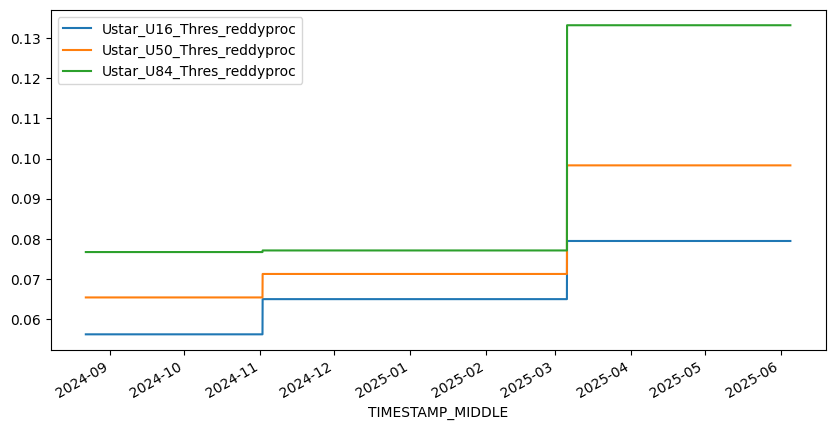

In [3]:
USTAR_SCENARIOS = ['Ustar_U16_Thres_reddyproc', 'Ustar_U50_Thres_reddyproc', 'Ustar_U84_Thres_reddyproc']
maindf[USTAR_SCENARIOS].plot(x_compat=True, figsize=(10, 5));

In [4]:
FLUX_VARS = [c for c in maindf.columns if 'L3.1_L3.2' in c]
TO_BE_FILTERED = ['NEE', 'FN2O', 'FCH4']
VARS_TO_FILTER = [c for c in FLUX_VARS if c.startswith(tuple(TO_BE_FILTERED))]
maindf[VARS_TO_FILTER]

,NEE_L3.1_L3.2_QCF,NEE_L3.1_L3.2_QCF0,FN2O_L3.1_L3.2_QCF,FN2O_L3.1_L3.2_QCF0,FCH4_L3.1_L3.2_QCF,FCH4_L3.1_L3.2_QCF0
TIMESTAMP_MIDDLE,,,,,,
2024-08-21 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-21 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-22 00:15:00,NaN,NaN,NaN,NaN,-1.304730,NaN
2024-08-22 00:45:00,NaN,NaN,0.365031,NaN,25.160860,NaN
2024-08-22 01:15:00,NaN,NaN,NaN,NaN,-30.113710,NaN
...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,10.578562,0.524032,0.524032,2.489636,NaN
2025-06-04 22:15:00,9.416519,9.416519,NaN,NaN,-0.987718,NaN
2025-06-04 22:45:00,10.095010,10.095010,-0.069384,-0.069384,2.160966,2.160966


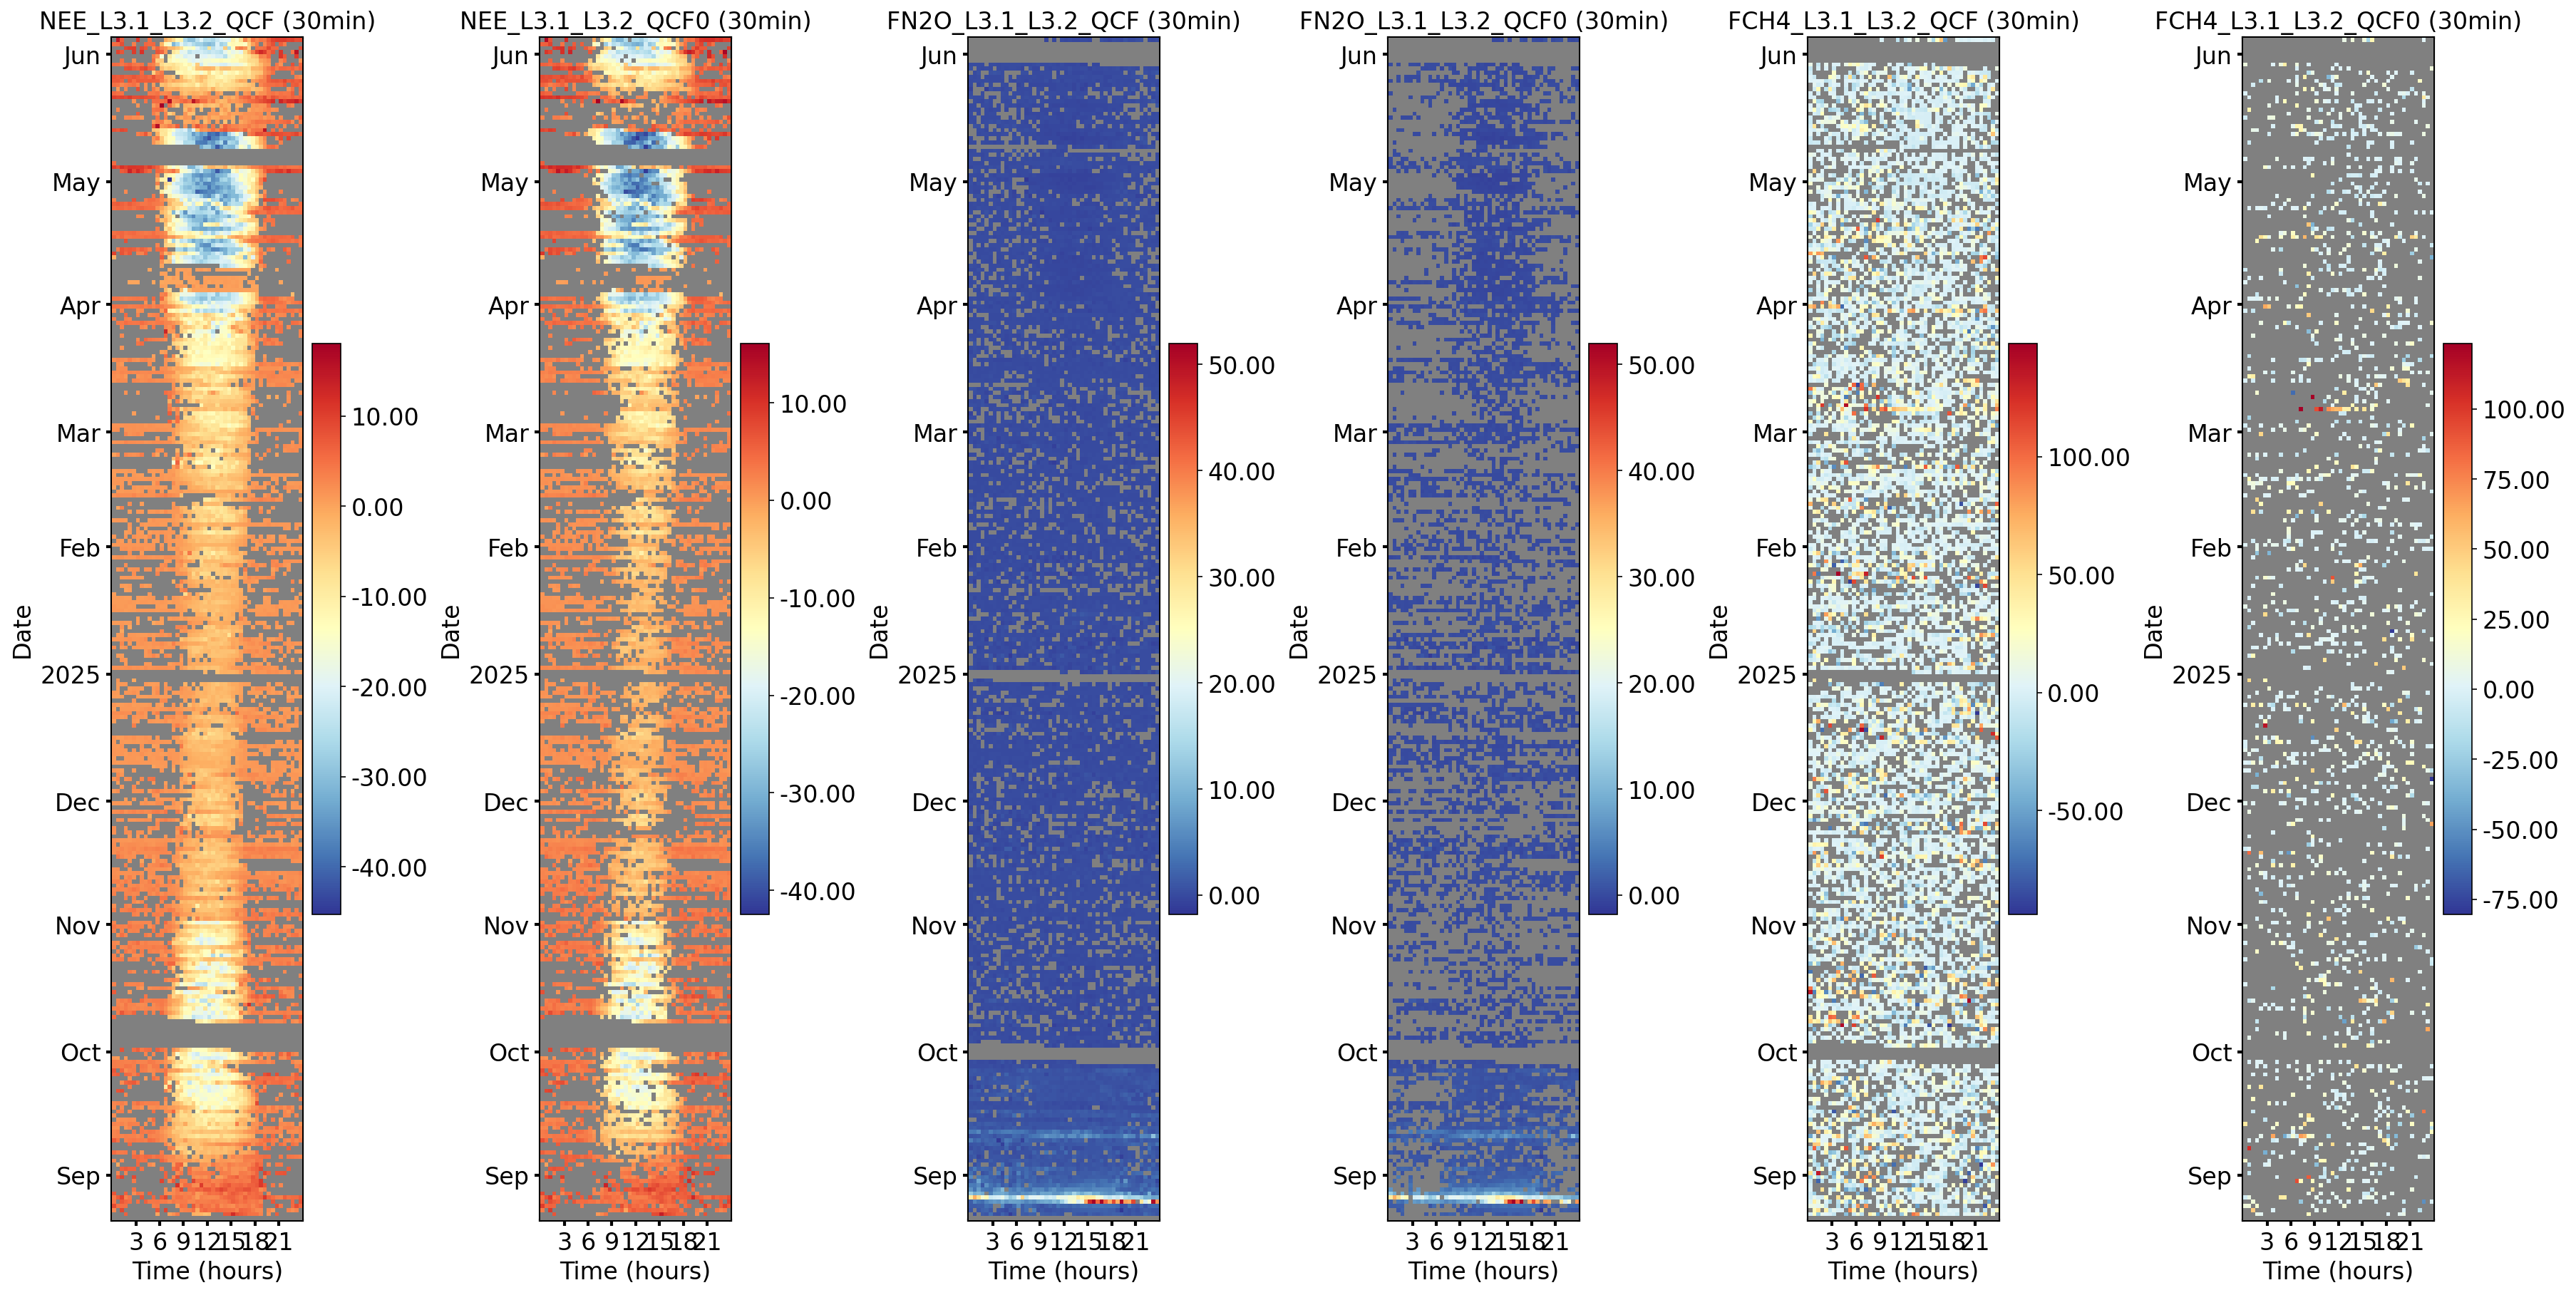

In [5]:
# Plot the fluxes that will be filtered

fig, axs = plt.subplots(ncols=6, nrows=1, figsize=(24, 12), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, VARS_TO_FILTER):
    HeatmapDateTime(series=maindf[var], ax=ax).plot()

</br>

</br>

---

# **USTAR FILTERING**

---

In [6]:
df_new = maindf.copy()

for var in VARS_TO_FILTER:
    n_total = df_new[var].notna().sum()   # valid values in original variable
    for cut in USTAR_SCENARIOS:
        CUT = cut[7:9]
        name_var = f"{var.split('_', 1)[0]}_L3.3_CUT_{CUT}_{var.rsplit('_', 1)[-1]}"
        name_flag = f"FLAG_L3.3_CUT_{CUT}_{var.split('_', 1)[0]}_L3.2_{var.rsplit('_', 1)[-1]}_USTAR_TEST"
        # Initialize if new
        if name_var not in df_new:
            df_new[name_var] = np.nan
        if name_flag not in df_new:
            df_new[name_flag] = 0.0
        valid_mask = df_new[var].notna()
        mask = df_new["USTAR"] > df_new[cut]
        df_new.loc[mask & valid_mask, name_var]  = df_new.loc[mask, var]
        df_new.loc[~mask & valid_mask, name_flag] = 2.0
        # Print stats
        n_out = (df_new[name_flag] == 2.0).sum()
        pct   = 100 * n_out / n_total if n_total > 0 else np.nan
        print(f"USTAR threshold CUT_{int(CUT)} removed "
              f"{n_out} values, {pct:.1f}% of {var}")

USTAR threshold CUT_16 removed 756 values, 8.9% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 1084 values, 12.7% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 1632 values, 19.1% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 565 values, 7.7% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 815 values, 11.2% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 1272 values, 17.4% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 1508 values, 14.0% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 2015 values, 18.7% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 2807 values, 26.1% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 437 values, 7.4% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 612 values, 10.4% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 944 values, 16.0% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 1278 values, 15.6% of FCH4_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 1706 values, 20.8% of FCH4_L3.1_L3.2_QCF
U

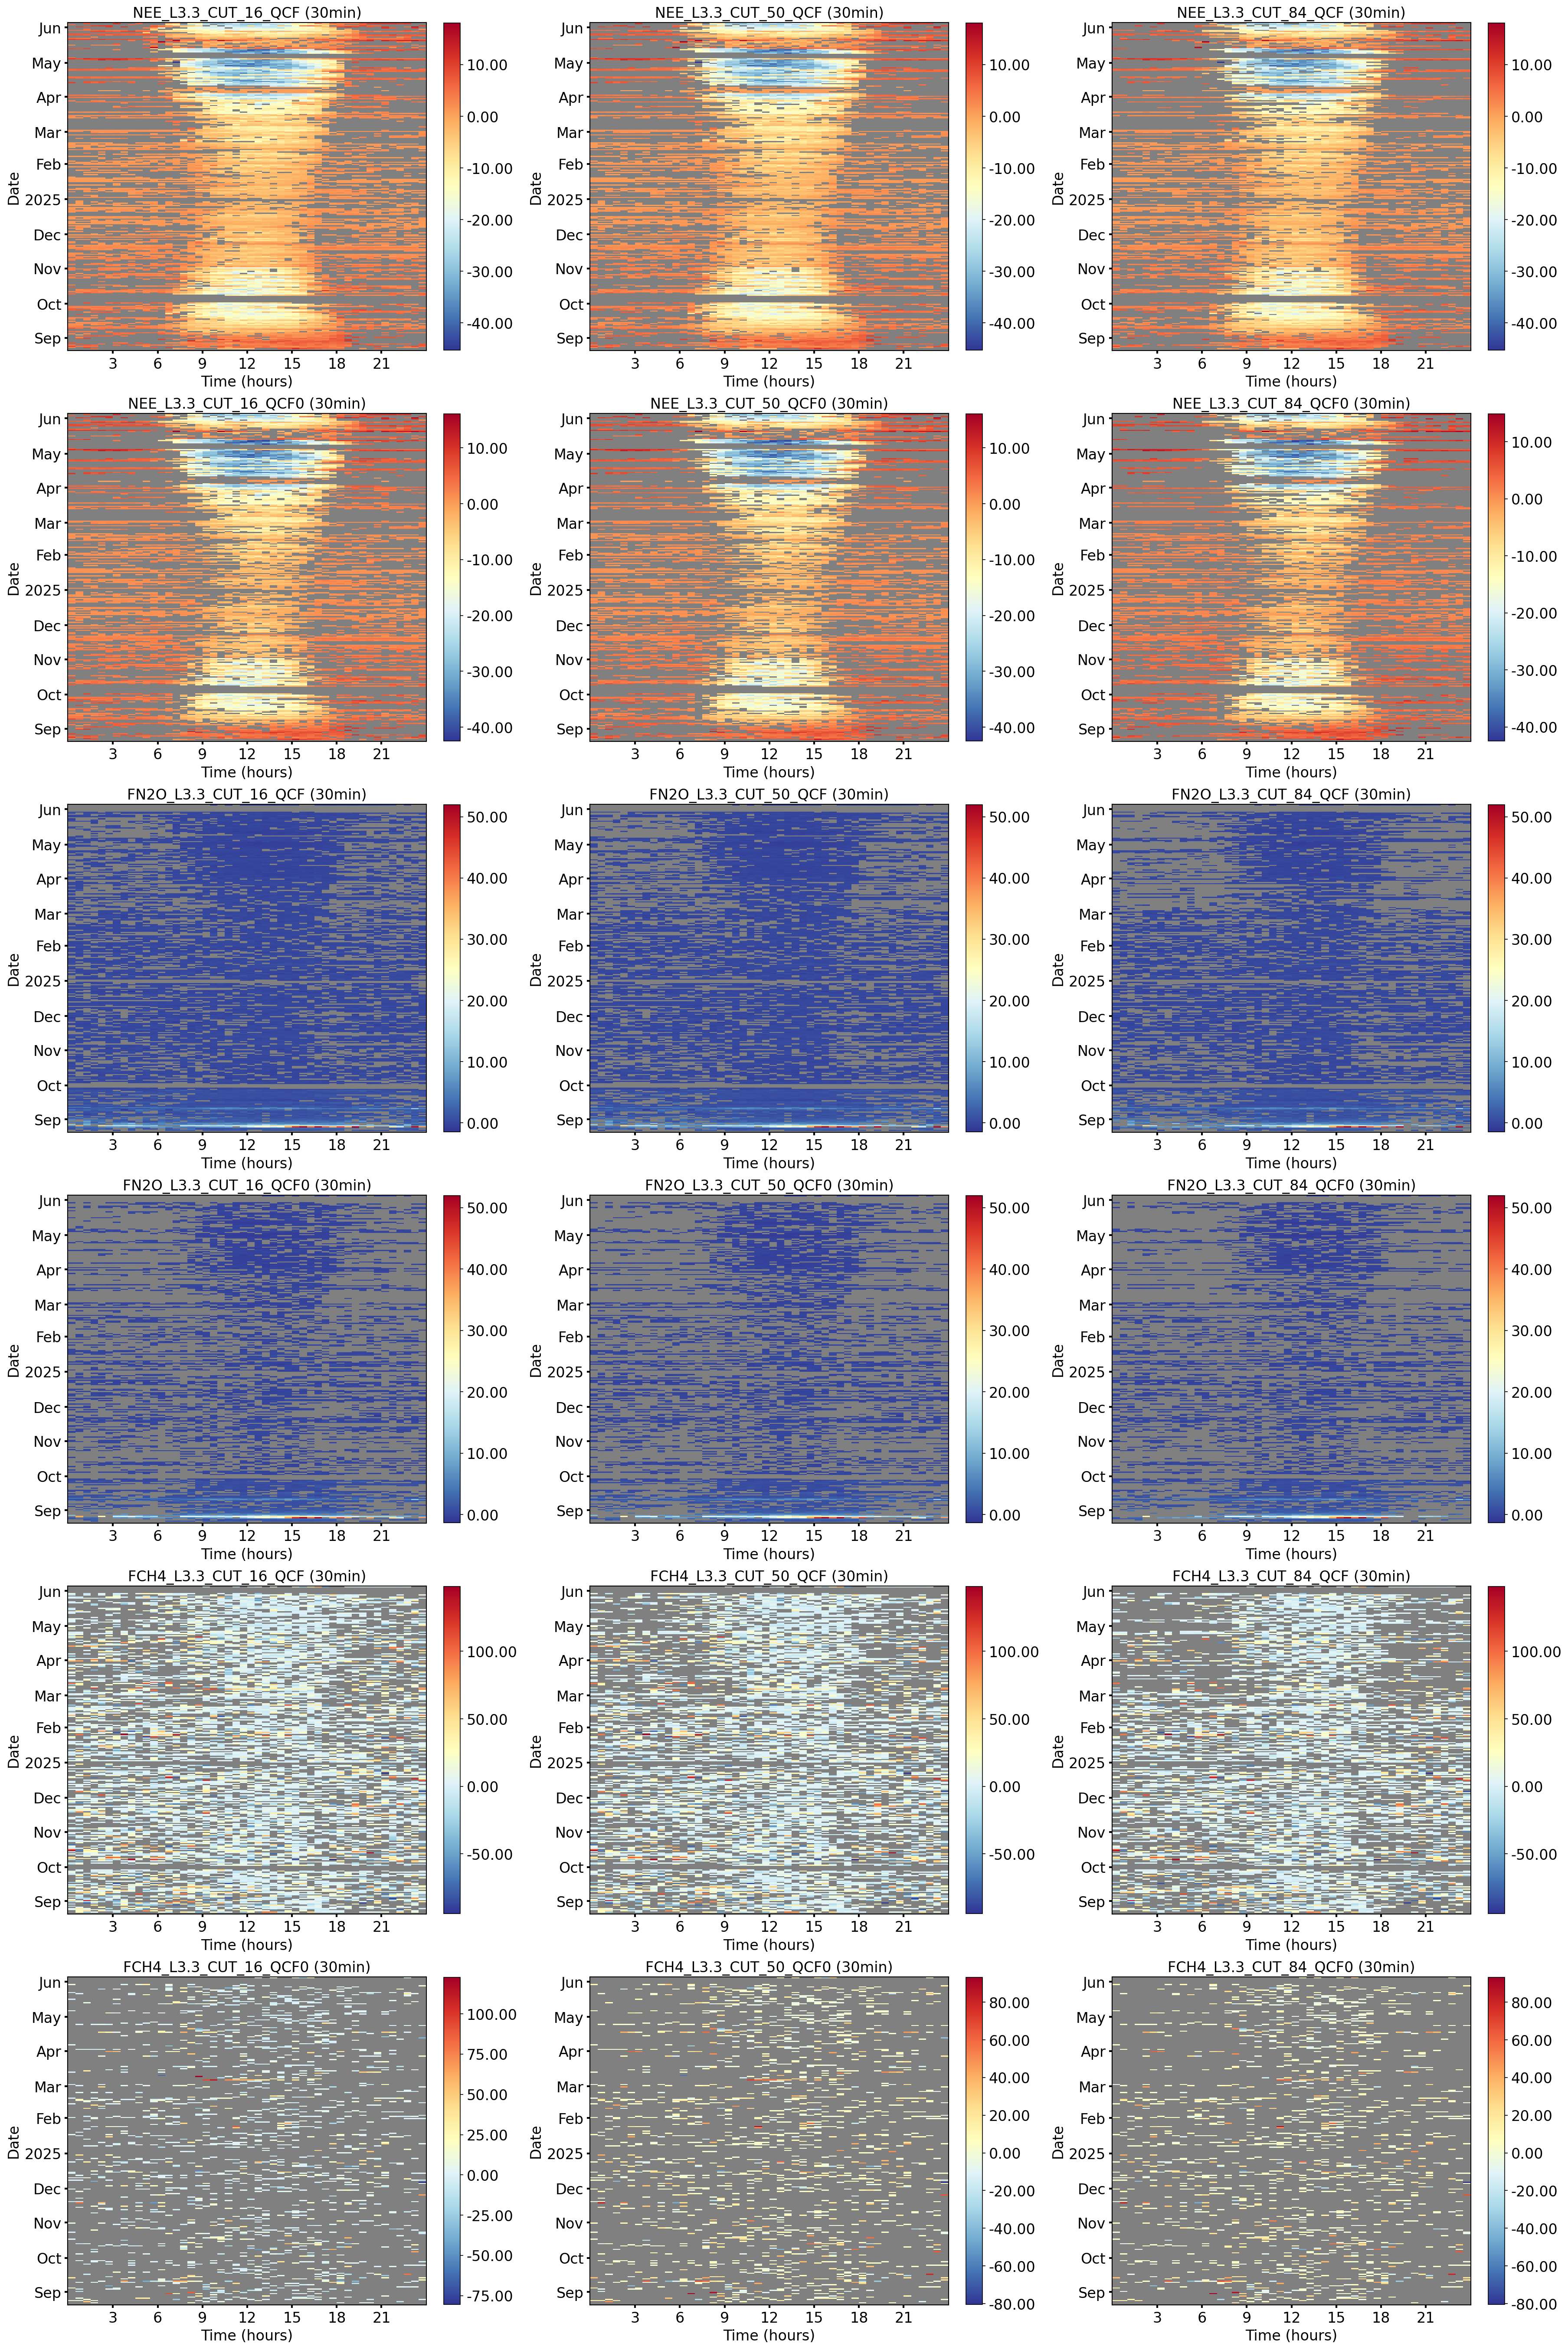

In [7]:
# Plot the ustar-filtered fluxes 
cols_to_plot  = [c for c in df_new.columns if 'CUT' in c and 'TEST' not in c]

fig, axs = plt.subplots(ncols=3, nrows=6, figsize=(24, 36), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, cols_to_plot):
    HeatmapDateTime(series=df_new[var], ax=ax).plot()

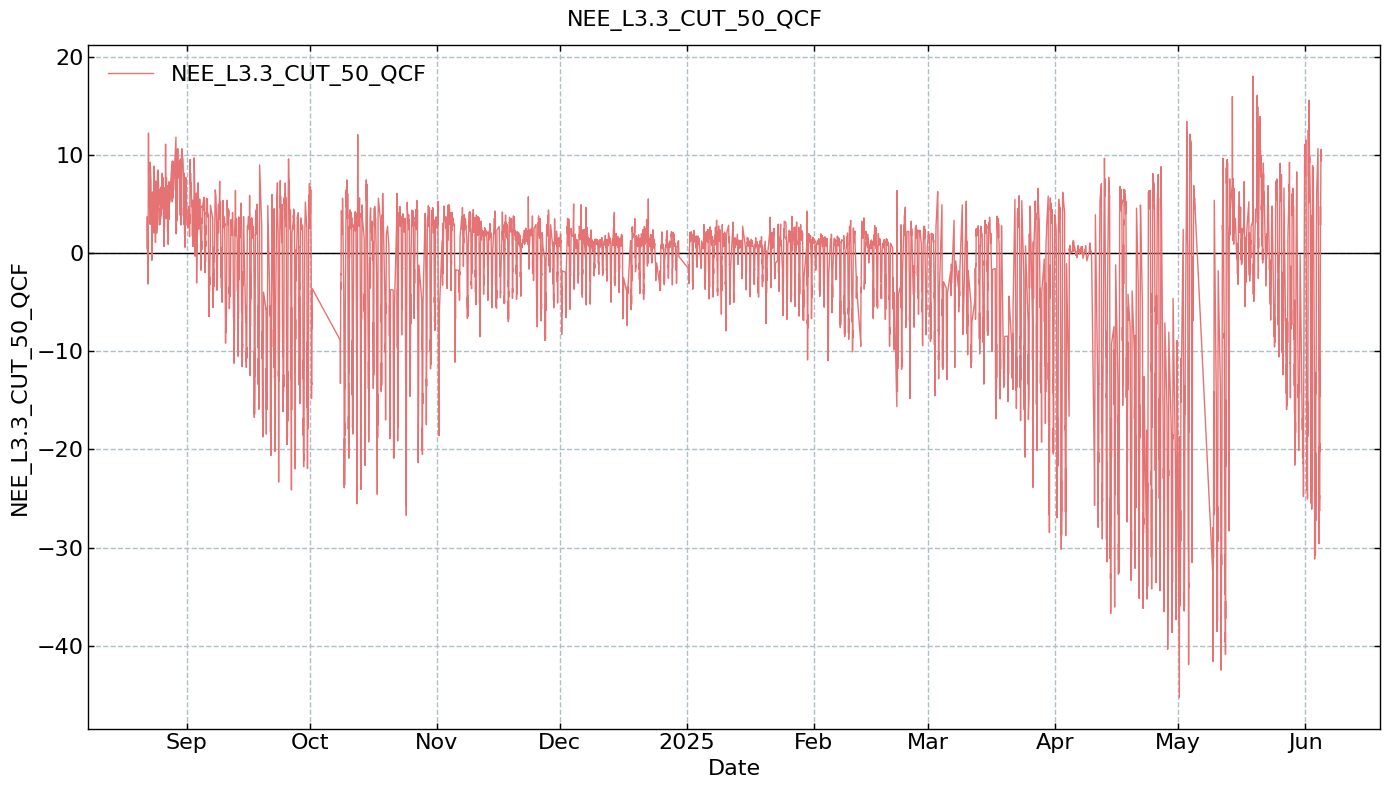

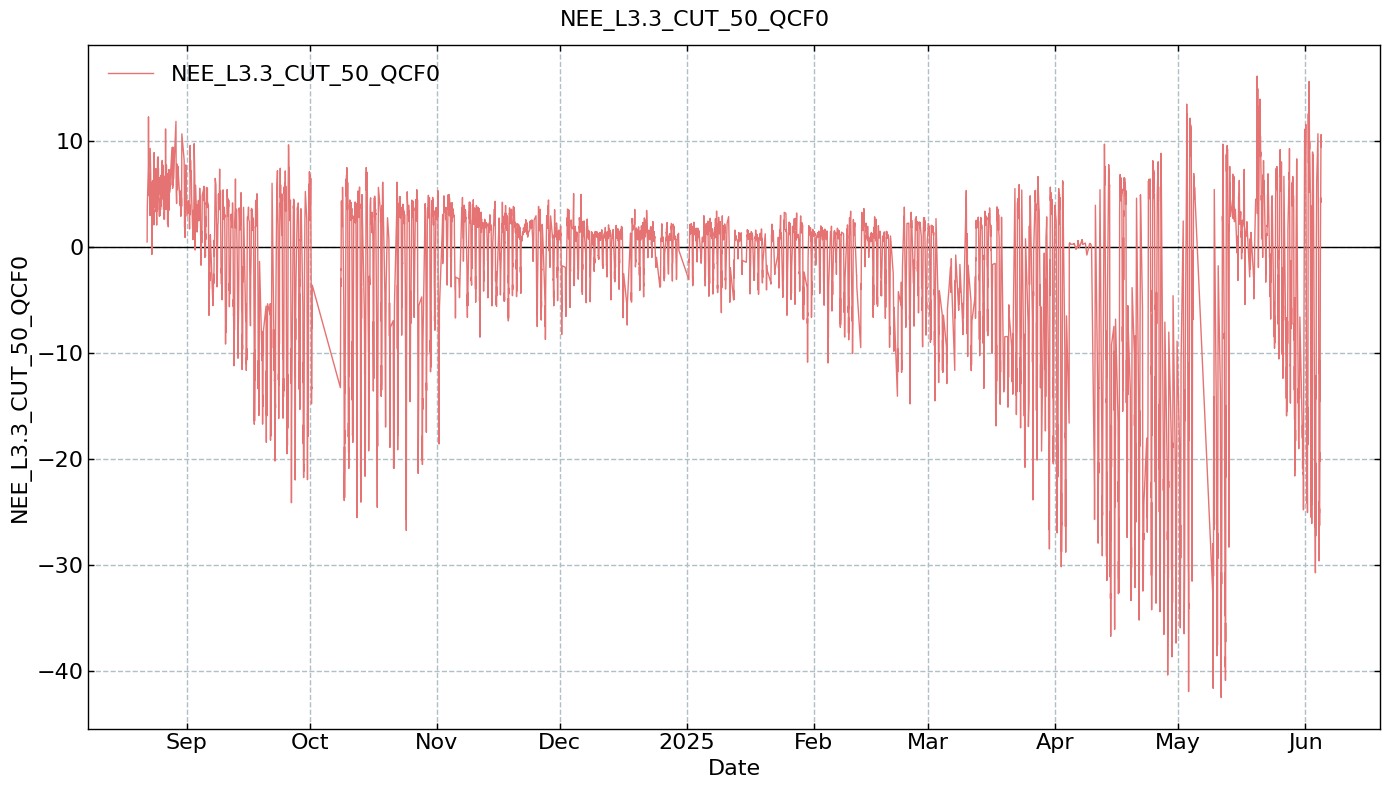

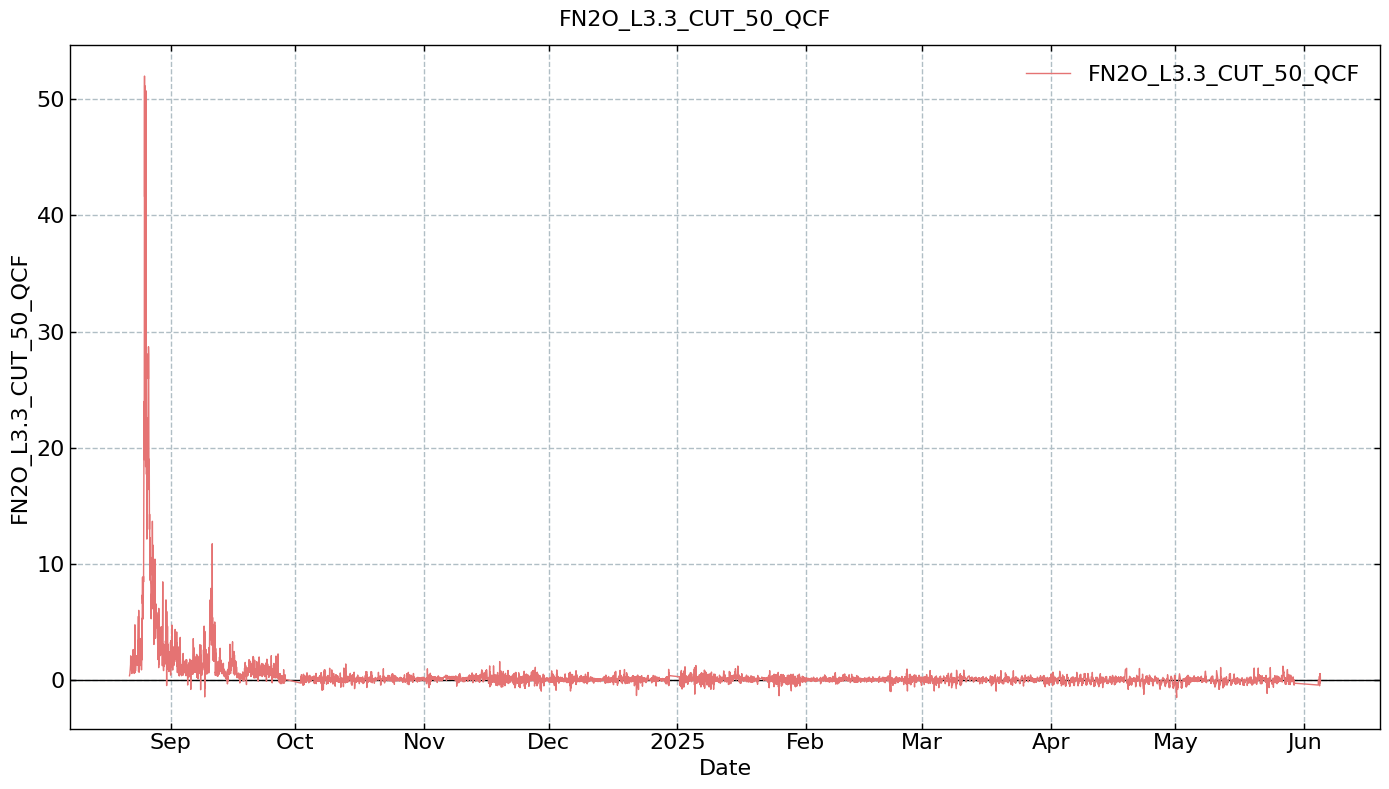

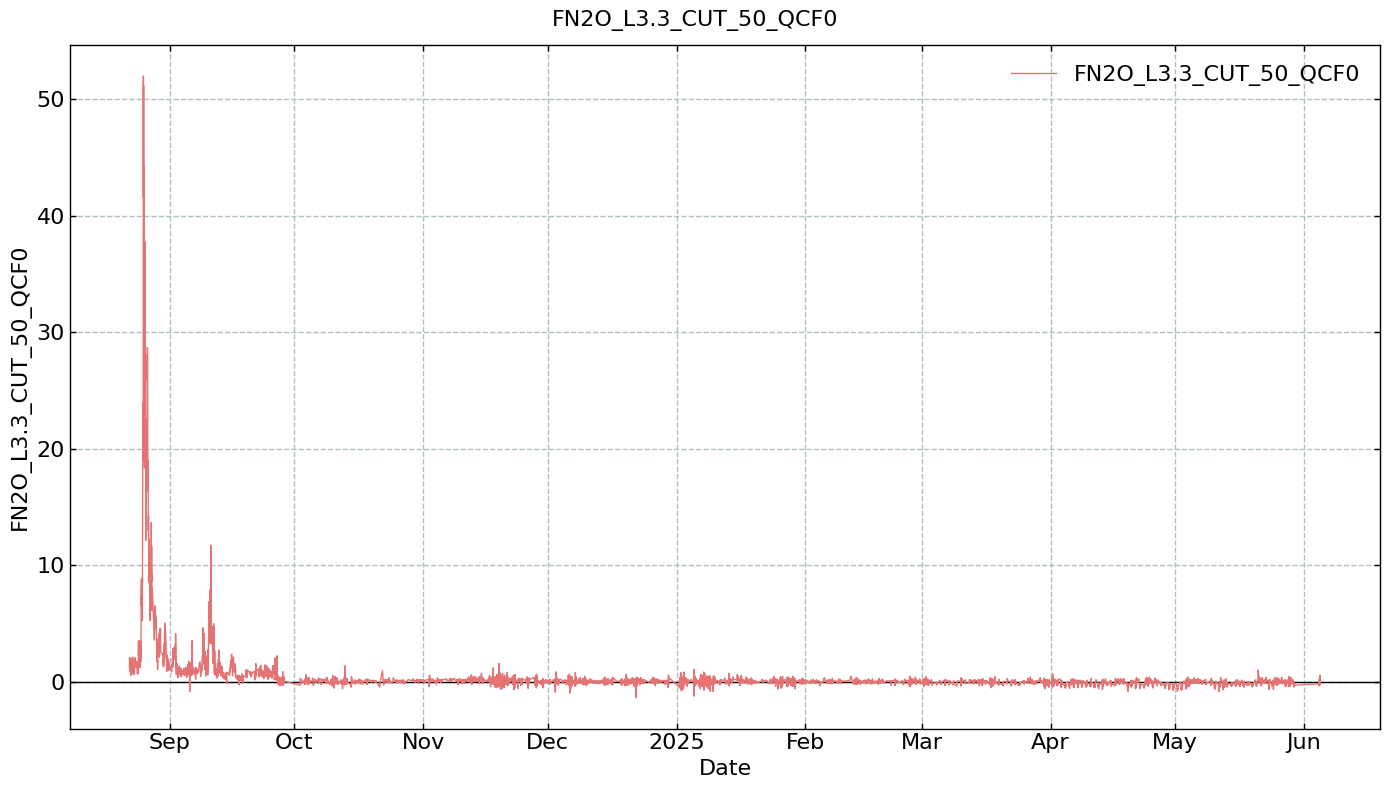

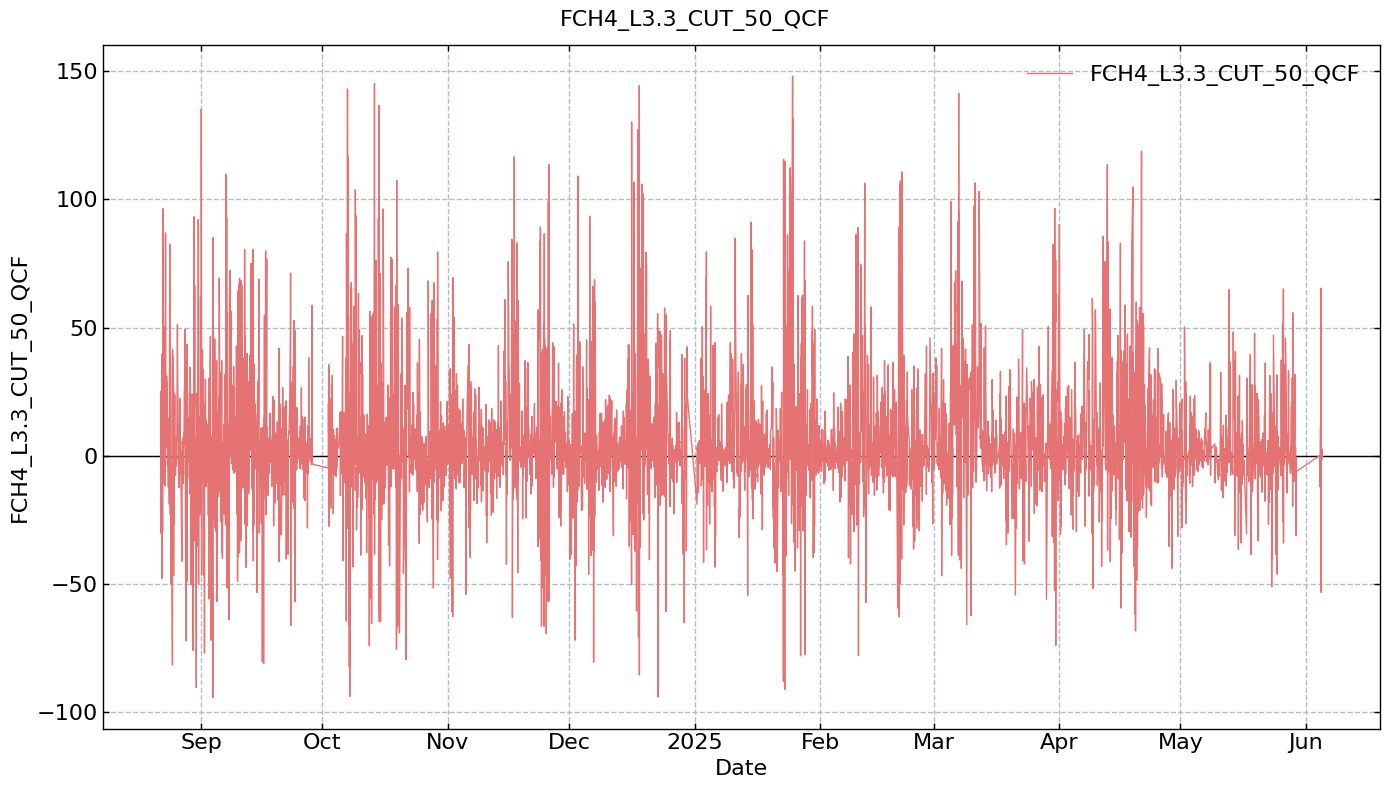

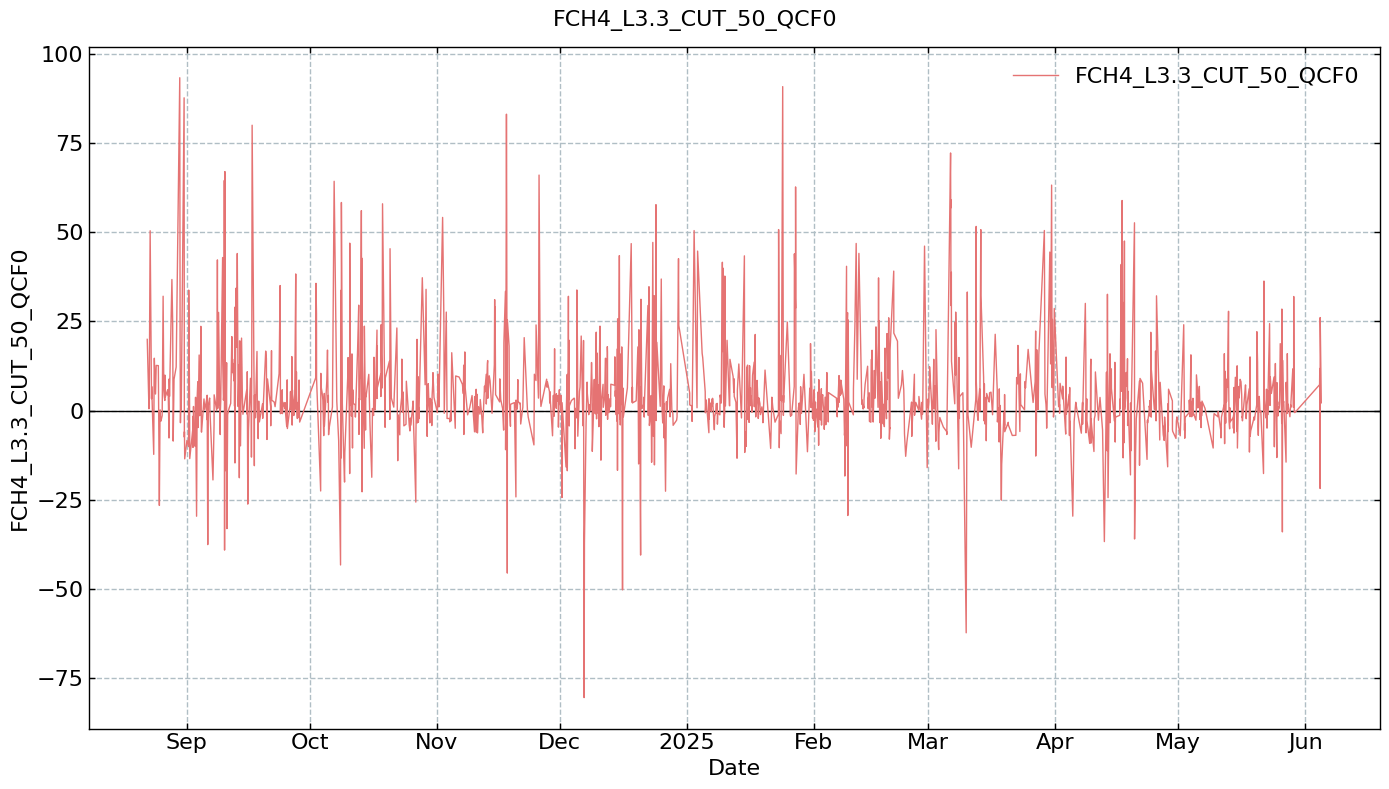

In [8]:
# Plot the variables that will be used in the next steps
for var in [c for c in cols_to_plot if '50' in c]:
    TimeSeries(series=df_new[var]).plot()

</br>

---

# **MERGE**

---

In [9]:
newcols = [c for c in df_new if c not in maindf]
print("NEW VARIABLES FROM USTAR FILTERING:")
[print(f"+ {c}") for c in newcols]
maindf = pd.concat([maindf, df_new[newcols]], axis=1)
maindf

NEW VARIABLES FROM USTAR FILTERING:
+ NEE_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST
+ FCH4_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_84_QCF
+ F

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-21 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2024-08-21 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2024-08-22 00:15:00,1012.16,1.16533,0.024738,1179.50,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,0.0,NaN,0.0,NaN,0.0
2024-08-22 00:45:00,1012.11,1.16619,0.024721,1180.31,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,25.160860,0.0,25.160860,0.0,NaN,2.0,NaN,0.0,NaN,0.0,NaN,0.0
2024-08-22 01:15:00,1012.10,1.16655,0.024713,1180.66,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,-30.113710,0.0,-30.113710,0.0,NaN,2.0,NaN,0.0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,1013.91,1.14074,0.025243,1156.61,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,0.524032,0.0,2.489636,0.0,2.489636,0.0,2.489636,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-04 22:15:00,1013.99,1.14144,0.025226,1157.41,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,NaN,0.0,-0.987718,0.0,-0.987718,0.0,-0.987718,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.069384,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0


---

# **EXPORT**

---

In [10]:
filename = "62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC"
save_parquet(data=maindf, filename=filename)

Saved file 62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.553 seconds).


'62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet'

---

# **End of notebook**

---

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-06 15:27:51
